# Physics-Informed Library Design for IDP SINDy

**Question**: Our degree-3 polynomial SINDy distillation yields 160/165 nonzero terms — near-dense. Would a physics-informed library basis do better?

**Two sub-questions:**
1. Are SE(3) forward kinematics atoms the right basis for IDP *dynamics* SINDy?
2. What about *policy* SINDy (behavioral cloning)? Does physics structure help there?

**Approach**: Compare 5 library choices on the same data across two tasks:
- **Dynamics fitting**: predict (Δx, Δθ₁, Δθ₂, Δẋ, Δθ̇₁, Δθ̇₂) from current state + action  
- **Policy fitting**: predict u from obs8  

Metrics: feature count, nonzero terms, condition number κ(Θ), RMSE.

### Library taxonomy

| Library | State coords | Degree | # features | Expected coverage |
|---------|-------------|--------|-------------|-------------------|
| A | angle [x,θ₁,θ₂,ẋ,θ̇₁,θ̇₂] | 3 | 120 | reference |
| B | SE(3) [x,s₁,c₁,s₁₂,c₁₂,ẋ,θ̇₁,θ̇₂] | 2 | 45 | gravity+kinematic ✓; Coriolis ✗ |
| C | SE(3) | 3 | 120 | all terms ✓ |
| D | Lagrangian custom ~35 atoms | SE(3) | ~35 | hand-crafted exact terms |
| E | obs8 [x,s₁,s₂,c₁,c₂,ẋ,θ̇₁,θ̇₂] | 3 | 165 | current distillation |

Libraries A–D target **dynamics**. Library E matches the current **policy distillation** setup.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pysindy as ps

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

L1 = L2 = 0.6
DT = 0.05
LAMBDA = 0.10

## Data loading

Two datasets:
- **Baseline trajectories**: 50k transitions in angle-space [x,θ₁,θ₂,ẋ,θ̇₁,θ̇₂] — for dynamics SINDy
- **Distillation dataset**: 300k (obs8, action) expert pairs — for policy SINDy

In [2]:
import pathlib
DATA = pathlib.Path('../data')

# ── Dynamics data (angle state) ──────────────────────────────────────────────
dyn = np.load(DATA / 'baseline/trajectories_baseline.npz')
X6      = dyn['X']       # (N, 6): [x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂]
U_dyn   = dyn['U']       # (N, 1)
X6_next = dyn['X_next']  # (N, 6)
dX6     = X6_next - X6   # increments
print(f'Dynamics transitions: {len(X6):,}')

# ── Policy data (obs8 + action) ──────────────────────────────────────────────
pol = np.load(DATA / 'distillation/dataset.npz')
# Undo standardization to get raw obs8
obs8_scaled = pol['obs_scaled']    # (300000, 8)
scaler_mean = pol['scaler_mean']   # (8,)
scaler_scale = pol['scaler_scale'] # (8,)
OBS8 = obs8_scaled * scaler_scale + scaler_mean  # raw obs8
U_pol = pol['actions']             # (300000,)
print(f'Policy transitions:   {len(OBS8):,}')
print(f'  obs8 labels: [x, sinθ₁, sinθ₂, cosθ₁, cosθ₂, ẋ, θ̇₁, θ̇₂]')
print(f'  obs8 ranges: min={OBS8.min(axis=0).round(2)}')
print(f'               max={OBS8.max(axis=0).round(2)}')

Dynamics transitions: 50,000
Policy transitions:   300,000
  obs8 labels: [x, sinθ₁, sinθ₂, cosθ₁, cosθ₂, ẋ, θ̇₁, θ̇₂]
  obs8 ranges: min=[-1.03 -0.67 -0.87  0.75  0.48 -2.65 -4.63 -5.97]
               max=[1.03 0.51 0.88 1.   1.   2.17 2.8  5.99]


## State representation transforms

The **SE(3) state** replaces raw angles with sin/cos of *absolute* link angles:
- θ₁: angle of link 1 from vertical → (s₁, c₁) = (sin θ₁, cos θ₁)
- θ₁+θ₂: absolute angle of link 2 → (s₁₂, c₁₂) = (sin(θ₁+θ₂), cos(θ₁+θ₂))

This is motivated by SE(3) forward kinematics: the FK of each link tip depends only on
sin/cos of the *cumulative* joint angle, not individual joint angles.

Key consequence:
- **Gravity** acts on the tip positions, which depend on s₁ and s₁₂ → degree-1 in SE(3) state (vs degree-2 in obs8 for s₁₂)
- **Coriolis** depends on sin(θ₂) = s₁₂·c₁ − c₁₂·s₁ → still degree-2 in SE(3) atoms (so degree-3 overall with a velocity factor)

The obs8 MuJoCo state uses (sinθ₁, sinθ₂, cosθ₁, cosθ₂) — sin/cos of *relative* angles. This gives sin(θ₂) directly at degree-1 but requires degree-2 for sin(θ₁+θ₂).

In [3]:
def state6_to_se3(X6):
    """[x,θ₁,θ₂,ẋ,θ̇₁,θ̇₂] → [x, s1, c1, s12, c12, ẋ, θ̇₁, θ̇₂]"""
    x, th1, th2 = X6[...,0], X6[...,1], X6[...,2]
    return np.stack([
        x,
        np.sin(th1),  np.cos(th1),
        np.sin(th1+th2), np.cos(th1+th2),
        X6[...,3], X6[...,4], X6[...,5],
    ], axis=-1)

# SE(3) state for dynamics data
Z8      = state6_to_se3(X6)
Z8_next = state6_to_se3(X6_next)
dZ8     = Z8_next - Z8

# obs8 to SE(3) state conversion (for policy data, MuJoCo obs has sinθ₂/cosθ₂ not sinα/cosα)
# OBS8: [x, sinθ₁, sinθ₂, cosθ₁, cosθ₂, ẋ, θ̇₁, θ̇₂]
#   sinα = sinθ₁·cosθ₂ + cosθ₁·sinθ₂
#   cosα = cosθ₁·cosθ₂ − sinθ₁·sinθ₂
def obs8_to_se3(obs8):
    x   = obs8[...,0]
    s1  = obs8[...,1]; s2 = obs8[...,2]
    c1  = obs8[...,3]; c2 = obs8[...,4]
    s12 = s1*c2 + c1*s2
    c12 = c1*c2 - s1*s2
    return np.stack([x, s1, c1, s12, c12, obs8[...,5], obs8[...,6], obs8[...,7]], axis=-1)

Z8_pol = obs8_to_se3(OBS8)

print('SE(3) state columns: [x, s1, c1, s12, c12, ẋ, θ̇₁, θ̇₂]')
print(f'SE(3) state unit-circle check (max |s1²+c1²-1|): {np.max(np.abs(Z8[:,1]**2+Z8[:,2]**2-1)):.2e}')
print(f'SE(3) state unit-circle check (max |s12²+c12²-1|): {np.max(np.abs(Z8[:,3]**2+Z8[:,4]**2-1)):.2e}')

SE(3) state columns: [x, s1, c1, s12, c12, ẋ, θ̇₁, θ̇₂]
SE(3) state unit-circle check (max |s1²+c1²-1|): 2.22e-16
SE(3) state unit-circle check (max |s12²+c12²-1|): 2.22e-16


## Library D: Lagrangian-derived custom library

From the Euler-Lagrange equations for the IDP cart system, the exact functional forms
that appear in the dynamics are:

**Kinematic rows** (trivial): Δx=ẋ·dt, Δθ₁=θ̇₁·dt, Δθ₂=θ̇₂·dt

**Velocity increment rows** (Δẋ, Δθ̇₁, Δθ̇₂) involve:
- Gravity: s₁, s₁₂ — degree-1 in SE(3) atoms ✓
- Mass matrix coupling: c₂ = c₁₂·c₁ + s₁₂·s₁ — degree-2 in SE(3) atoms
- Centripetal: s₁·θ̇₁², s₁₂·θ̇₁², s₁₂·θ̇₁θ̇₂, s₁₂·θ̇₂² — degree-2
- Coriolis: s₂·θ̇₁², s₂·θ̇₂², s₂·θ̇₁θ̇₂ where s₂ = s₁₂·c₁−c₁₂·s₁ — degree-3
- Cart-link coupling: s₁₂·ẋ, c₁·ẋ — degree-2
- Control: u — degree-1 (control-affine)

Total: ~35 hand-crafted atoms (vs 120 for degree-3 polynomial in SE(3) state).
In principle, the dynamics should be representable with ≤8 nonzero per output row.

In [4]:
def lagrangian_library(Z8, U):
    """
    Physics-derived library for IDP dynamics in SE(3) state.
    Z8: (N,8) [x, s1, c1, s12, c12, dx, dth1, dth2]
    U:  (N,1) control action
    Returns (Theta, feature_names), shape (N, ~35).
    """
    x   = Z8[:,0]
    s1  = Z8[:,1];  c1  = Z8[:,2]
    s12 = Z8[:,3];  c12 = Z8[:,4]
    dx  = Z8[:,5];  dt1 = Z8[:,6];  dt2 = Z8[:,7]
    u   = U[:,0]

    # Derived: relative-angle sin/cos
    # sin(θ₂) = sin(α−θ₁) = s12·c1 − c12·s1
    # cos(θ₂) = cos(α−θ₁) = c12·c1 + s12·s1
    s2 = s12 * c1 - c12 * s1
    c2 = c12 * c1 + s12 * s1

    # ── Degree-1: kinematics + gravity + control ──────────────────────────
    d1 = {
        'dx':  dx,  'dth1': dt1,  'dth2': dt2,
        's1':  s1,  'c1':   c1,
        's12': s12, 'c12':  c12,
        'u':   u,
    }

    # ── Degree-2: velocity products (centrifugal/Coriolis) ────────────────
    d2_vel = {
        'dx^2':      dx**2,
        'dth1^2':    dt1**2,
        'dth2^2':    dt2**2,
        'dth1 dth2': dt1 * dt2,
        'dx dth1':   dx  * dt1,
        'dx dth2':   dx  * dt2,
    }

    # ── Degree-2: angle-velocity (mass matrix × angular velocity) ─────────
    d2_av = {
        's1 dth1':  s1  * dt1,
        'c1 dth1':  c1  * dt1,
        's12 dth1': s12 * dt1,
        'c12 dth1': c12 * dt1,
        's12 dth2': s12 * dt2,
        'c12 dth2': c12 * dt2,
        's1 dx':    s1  * dx,
        's12 dx':   s12 * dx,
        'c12 dx':   c12 * dx,
    }

    # ── Relative-angle atoms (sin/cos θ₂: degree-2 in SE3 atoms) ─────────
    d2_rel = {
        's2': s2,   # sin(θ₂) = s12·c1 − c12·s1
        'c2': c2,   # cos(θ₂) = c12·c1 + s12·s1
    }

    # ── Degree-3: Coriolis coupling (sin(θ₂) × velocity²) ────────────────
    d3_cor = {
        's2 dth1^2':    s2 * dt1**2,
        's2 dth2^2':    s2 * dt2**2,
        's2 dth1 dth2': s2 * dt1 * dt2,
        'c2 dth1^2':    c2 * dt1**2,     # appears in some EOM cross-terms
        'c2 dth2^2':    c2 * dt2**2,
    }

    # ── Degree-3: control × coupling (if not strictly control-affine) ─────
    d3_ctrl = {
        'c1 u':   c1  * u,
        'c12 u':  c12 * u,
    }

    atoms = {**d1, **d2_vel, **d2_av, **d2_rel, **d3_cor, **d3_ctrl}
    names  = list(atoms.keys())
    Theta  = np.column_stack(list(atoms.values()))
    return Theta, names


# Verify it runs
Theta_D, names_D = lagrangian_library(Z8[:5], U_dyn[:5])
print(f'Lagrangian library: {Theta_D.shape[1]} features')
print('Features:', names_D)

Lagrangian library: 32 features
Features: ['dx', 'dth1', 'dth2', 's1', 'c1', 's12', 'c12', 'u', 'dx^2', 'dth1^2', 'dth2^2', 'dth1 dth2', 'dx dth1', 'dx dth2', 's1 dth1', 'c1 dth1', 's12 dth1', 'c12 dth1', 's12 dth2', 'c12 dth2', 's1 dx', 's12 dx', 'c12 dx', 's2', 'c2', 's2 dth1^2', 's2 dth2^2', 's2 dth1 dth2', 'c2 dth1^2', 'c2 dth2^2', 'c1 u', 'c12 u']


## Fit all libraries on dynamics data

Fit STLSQ at λ=0.10 for each library. Record RMSE, nonzero count per output,
and condition number κ(Θ).

In [5]:
from sklearn.preprocessing import PolynomialFeatures

def poly_features(state_matrix, degree, feature_names_in, include_bias=False):
    pf = PolynomialFeatures(degree, include_bias=include_bias)
    Theta = pf.fit_transform(state_matrix)
    names = pf.get_feature_names_out(feature_names_in)
    return Theta, list(names)

def stlsq(Theta, dX, lam=LAMBDA, max_iter=20):
    """Sequentially Thresholded Least Squares. Returns coefficient matrix (n_out, n_feat)."""
    Xi = np.linalg.lstsq(Theta, dX, rcond=None)[0]
    for _ in range(max_iter):
        mask = np.abs(Xi) >= lam
        for j in range(dX.shape[1]):
            idx = mask[:, j]
            if idx.sum() == 0:
                Xi[:, j] = 0
            else:
                Xi[~idx, j] = 0
                Xi[idx,  j] = np.linalg.lstsq(Theta[:, idx], dX[:, j], rcond=None)[0]
    return Xi.T   # (n_out, n_feat)

def rmse(pred, true):
    return np.sqrt(np.mean((pred - true)**2, axis=0))

def analyze(Theta, Xi, dX, names, label):
    """Compute per-output nonzero count, RMSE, and overall κ."""
    pred  = Theta @ Xi.T
    r     = rmse(pred, dX)
    nz    = (np.abs(Xi) > 0).sum(axis=1)
    kappa = np.linalg.cond(Theta)
    total_nz = nz.sum()
    out_labels = ['Δx', 'Δθ1', 'Δθ2', 'Δẋ', 'Δθ̇1', 'Δθ̇2']
    print(f'\n── {label} ({Theta.shape[1]} features, κ={kappa:.2e}) ──')
    print(f'  Total nonzero: {total_nz} / {Theta.shape[1] * 6}')
    print(f'  {"Output":8s}  {"Nonzero":>7s}  {"RMSE":>10s}')
    for i, lbl in enumerate(out_labels):
        print(f'  {lbl:8s}  {nz[i]:>7d}  {r[i]:>10.5f}')
    print(f'  Mean RMSE: {r.mean():.5f}')
    return {'label': label, 'n_feat': Theta.shape[1], 'kappa': kappa,
            'total_nz': total_nz, 'nz_per_out': nz, 'rmse_per_out': r, 'mean_rmse': r.mean(),
            'Xi': Xi, 'names': names}


# Subsample for speed (use 30k for fitting, 5k test)
rng = np.random.default_rng(0)
idx = rng.permutation(len(X6))
idx_tr, idx_te = idx[:30_000], idx[30_000:35_000]

dX_tr  = dX6[idx_tr];   dX_te  = dX6[idx_te]
dZ_tr  = dZ8[idx_tr];   dZ_te  = dZ8[idx_te]

results = {}

# ── Library A: angle state + degree-3 ────────────────────────────────────────
NAMES6 = ['x','th1','th2','dx','dth1','dth2']
XU_tr = np.hstack([X6[idx_tr], U_dyn[idx_tr]])
XU_te = np.hstack([X6[idx_te], U_dyn[idx_te]])
Th_A_tr, nm_A = poly_features(XU_tr, 3, NAMES6 + ['u'])
Th_A_te, _   = poly_features(XU_te, 3, NAMES6 + ['u'])
Xi_A = stlsq(Th_A_tr, dX_tr)
results['A'] = analyze(Th_A_te, Xi_A, dX_te, nm_A, 'Library A: angle + deg-3')

# ── Library B: SE(3) state + degree-2 ────────────────────────────────────────
NAMES8 = ['x','s1','c1','s12','c12','dx','dth1','dth2']
ZU_tr = np.hstack([Z8[idx_tr], U_dyn[idx_tr]])
ZU_te = np.hstack([Z8[idx_te], U_dyn[idx_te]])
Th_B_tr, nm_B = poly_features(ZU_tr, 2, NAMES8 + ['u'])
Th_B_te, _   = poly_features(ZU_te, 2, NAMES8 + ['u'])
Xi_B = stlsq(Th_B_tr, dX_tr)
results['B'] = analyze(Th_B_te, Xi_B, dX_te, nm_B, 'Library B: SE(3) + deg-2')

# ── Library C: SE(3) state + degree-3 ────────────────────────────────────────
Th_C_tr, nm_C = poly_features(ZU_tr, 3, NAMES8 + ['u'])
Th_C_te, _   = poly_features(ZU_te, 3, NAMES8 + ['u'])
Xi_C = stlsq(Th_C_tr, dX_tr)
results['C'] = analyze(Th_C_te, Xi_C, dX_te, nm_C, 'Library C: SE(3) + deg-3')

# ── Library D: Lagrangian custom library ──────────────────────────────────────
Th_D_tr, nm_D = lagrangian_library(Z8[idx_tr], U_dyn[idx_tr])
Th_D_te, _   = lagrangian_library(Z8[idx_te], U_dyn[idx_te])
Xi_D = stlsq(Th_D_tr, dX_tr)
results['D'] = analyze(Th_D_te, Xi_D, dX_te, nm_D, 'Library D: Lagrangian custom')


── Library A: angle + deg-3 (119 features, κ=1.17e+06) ──
  Total nonzero: 245 / 714
  Output    Nonzero        RMSE
  Δx             13     0.03207
  Δθ1            14     0.04349
  Δθ2            20     0.04548
  Δẋ             41     0.05609
  Δθ̇1           67     0.12601
  Δθ̇2           90     0.15805
  Mean RMSE: 0.07687

── Library B: SE(3) + deg-2 (54 features, κ=1.44e+17) ──
  Total nonzero: 163 / 324
  Output    Nonzero        RMSE
  Δx             14     0.03399
  Δθ1            19     0.04551
  Δθ2            19     0.04762
  Δẋ             32     0.06071
  Δθ̇1           36     0.12926
  Δθ̇2           43     0.18149
  Mean RMSE: 0.08310

── Library C: SE(3) + deg-3 (219 features, κ=2.09e+19) ──
  Total nonzero: 904 / 1314
  Output    Nonzero        RMSE
  Δx            102     0.00633
  Δθ1           114     0.01046
  Δθ2           125     0.01658
  Δẋ            182     0.26016
  Δθ̇1          185     0.52490
  Δθ̇2          196     0.68272
  Mean RMSE: 0.25019

── Lib

## Summary comparison table

In [6]:
print('\n' + '='*72)
print(f'  {"Library":<30s}  {"#Feat":>6s}  {"κ":>10s}  {"Nonzero":>8s}  {"RMSE":>8s}')
print('='*72)
for key, r in results.items():
    print(f'  {r["label"]:<30s}  {r["n_feat"]:>6d}  '
          f'{r["kappa"]:>10.2e}  {r["total_nz"]:>8d}  {r["mean_rmse"]:>8.5f}')
print('='*72)
print('Note: nonzero = sum over 6 output dimensions at λ=0.10')

# Per-output breakdown
out_labels = ['Δx', 'Δθ₁', 'Δθ₂', 'Δẋ', 'Δθ̇₁', 'Δθ̇₂']
print('\nNonzero terms per output dimension:')
print(f'  {"":30s}  ' + '  '.join(f'{l:>5s}' for l in out_labels))
for key, r in results.items():
    nz = r['nz_per_out']
    print(f'  {r["label"]:30s}  ' + '  '.join(f'{n:>5d}' for n in nz))


  Library                          #Feat           κ   Nonzero      RMSE
  Library A: angle + deg-3           119    1.17e+06       245   0.07687
  Library B: SE(3) + deg-2            54    1.44e+17       163   0.08310
  Library C: SE(3) + deg-3           219    2.09e+19       904   0.25019
  Library D: Lagrangian custom        32    3.35e+04        65   0.08567
Note: nonzero = sum over 6 output dimensions at λ=0.10

Nonzero terms per output dimension:
                                     Δx    Δθ₁    Δθ₂     Δẋ   Δθ̇₁   Δθ̇₂
  Library A: angle + deg-3           13     14     20     41     67     90
  Library B: SE(3) + deg-2           14     19     19     32     36     43
  Library C: SE(3) + deg-3          102    114    125    182    185    196
  Library D: Lagrangian custom        0      3      3     18     21     20


## Condition number anatomy

The condition number κ(Θ) tells us how sensitive STLSQ coefficient estimates are to
data noise. High κ means small coefficients along ill-conditioned directions are numerically
unreliable — STLSQ can't confidently zero them.

We expect: κ(Lagrangian) ≪ κ(deg-3 polynomial).

The singular value spectrum shows *how* the conditioning differs.

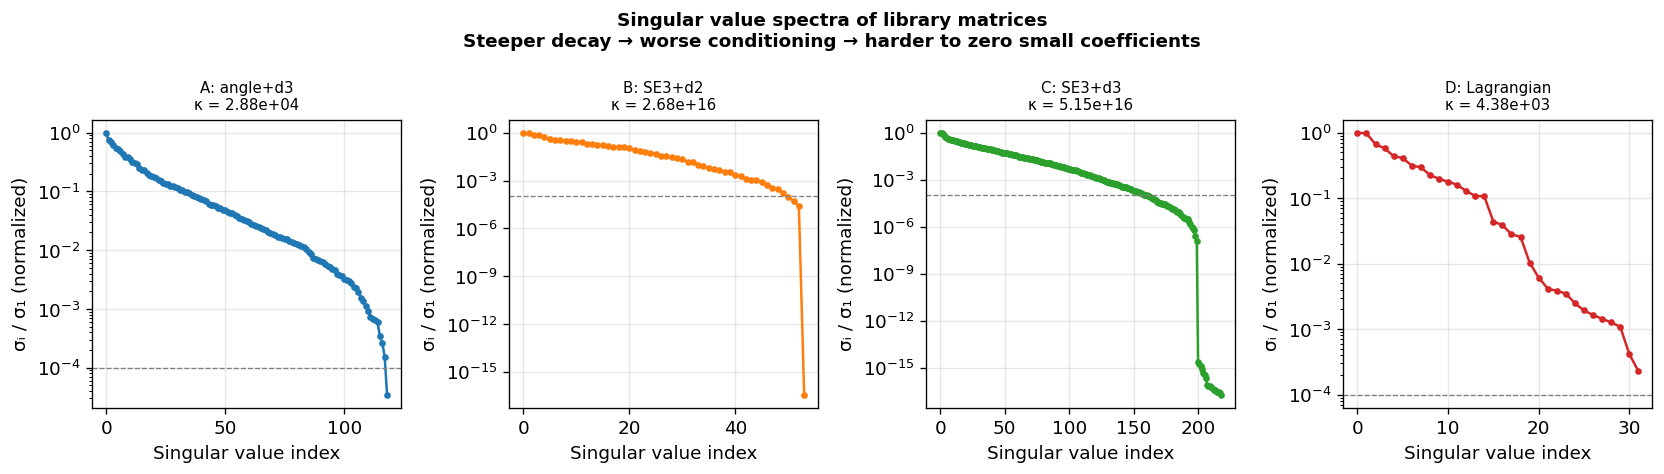

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
library_matrices = [
    (Th_A_tr, 'A: angle+d3', 'C0'),
    (Th_B_tr, 'B: SE3+d2',  'C1'),
    (Th_C_tr, 'C: SE3+d3',  'C2'),
    (Th_D_tr, 'D: Lagrangian','C3'),
]

for ax, (Th, label, color) in zip(axes, library_matrices):
    # Normalize columns before SVD (as STLSQ would see a standardized problem)
    col_norms = np.linalg.norm(Th, axis=0, keepdims=True)
    col_norms[col_norms == 0] = 1
    Th_norm = Th / col_norms
    sv = np.linalg.svd(Th_norm, compute_uv=False)
    kappa = sv[0] / sv[-1]
    ax.semilogy(sv / sv[0], '-o', color=color, markersize=3)
    ax.set_title(f'{label}\nκ = {kappa:.2e}', fontsize=9)
    ax.set_xlabel('Singular value index')
    ax.set_ylabel('σᵢ / σ₁ (normalized)')
    ax.axhline(1e-4, color='gray', ls='--', lw=0.8, label='1e-4 threshold')
    ax.grid(True, alpha=0.3)

fig.suptitle('Singular value spectra of library matrices\n'
             'Steeper decay → worse conditioning → harder to zero small coefficients',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Sparsity patterns — Lagrangian library

Which atoms survive STLSQ in the Lagrangian library? Compare to expected structure from EOM.

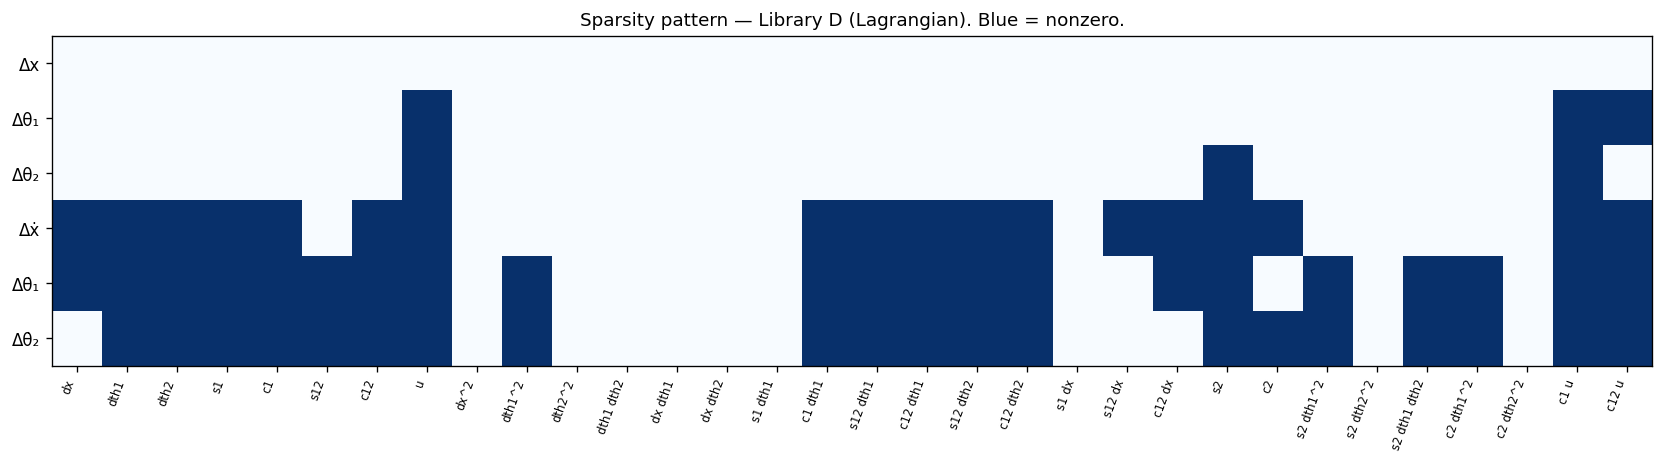

Surviving terms per dynamic output (Library D):
  Δx: (none)
  Δθ₁: 3 terms
      -1.1503 · c12 u
      +0.6221 · c1 u
      +0.5285 · u
  Δθ₂: 3 terms
      -1.3197 · u
      +1.3135 · c1 u
      -0.3747 · s2
  Δẋ: 18 terms
      +11.2407 · c12 u
      -9.7202 · u
      +6.8094 · c12 dth1
      -6.2531 · dth1
      -6.0013 · dx
      +5.9984 · c12 dx
      +3.0543 · c12 dth2
      -3.0523 · dth2
      -0.8975 · c2
      +0.6487 · c12
      +0.6193 · c1 u
      -0.5663 · c1 dth1
      +0.2505 · c1
      +0.2497 · s2
      -0.2488 · s12 dth1
      -0.1437 · s1
      -0.1369 · s12 dth2
      -0.1162 · s12 dx
  Δθ̇₁: 21 terms
      +18.6032 · u
      -15.0027 · c12 u
      -14.5172 · s2
      +13.4339 · s12
      -12.0223 · s1
      -8.0040 · c1 u
      +3.6005 · dx
      -3.5727 · c12 dx
      -2.7644 · c12 dth1
      +1.9269 · dth1
      +0.9315 · c1 dth1
      -0.8050 · c12
      +0.8029 · c1
      +0.5494 · dth2
      -0.5328 · c12 dth2
      +0.2649 · s12 dth1
      +0.2084 · c2 dth1

In [8]:
out_labels = ['Δx', 'Δθ₁', 'Δθ₂', 'Δẋ', 'Δθ̇₁', 'Δθ̇₂']
Xi_D_show = results['D']['Xi']  # (6, n_feat)
names_D_show = results['D']['names']

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(np.abs(Xi_D_show) > 0, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax.set_yticks(range(6)); ax.set_yticklabels(out_labels, fontsize=10)
ax.set_xticks(range(len(names_D_show)))
ax.set_xticklabels(names_D_show, rotation=70, ha='right', fontsize=7)
ax.set_title('Sparsity pattern — Library D (Lagrangian). Blue = nonzero.', fontsize=11)
plt.tight_layout()
plt.show()

# Print surviving terms with coefficients for each dynamic row
print('Surviving terms per dynamic output (Library D):')
for i, lbl in enumerate(out_labels):
    nz_idx = np.where(np.abs(Xi_D_show[i]) > 0)[0]
    if len(nz_idx) == 0:
        print(f'  {lbl}: (none)')
    else:
        terms = [(names_D_show[j], Xi_D_show[i,j]) for j in nz_idx]
        terms.sort(key=lambda t: -abs(t[1]))
        print(f'  {lbl}: {len(terms)} terms')
        for name, coef in terms:
            print(f'      {coef:+.4f} · {name}')

## Policy distillation: does physics structure help?

For dynamics SINDy, the Lagrangian provides the right library because the target (next state)
is generated by the physics. For **policy SINDy** (obs → u), the target is generated by
the RL optimizer — it has no Lagrangian structure.

Near upright, the optimal policy should resemble LQR: u ≈ K·obs (linear, 8 terms).
We test whether restricting to a small physics-informed library loses accuracy vs the
current degree-3 obs8 library (165 terms).

Library choices for policy:
- **E**: obs8 + degree-3 (current, 165 terms)
- **F**: SE(3) state + degree-3 (120 terms, same feature count as deg-3 on angle state)
- **G**: linear obs8 (8 terms — LQR-like baseline)
- **H**: quadratic obs8 (44 terms)

In [9]:
# Subsample policy data
rng2 = np.random.default_rng(1)
idx_p = rng2.permutation(len(OBS8))
idx_ptr, idx_pte = idx_p[:50_000], idx_p[50_000:60_000]

U_tr_p  = U_pol[idx_ptr,  None];   U_te_p  = U_pol[idx_pte, None]

pol_results = {}
NAMES_OBS8 = ['x','s1','s2','c1','c2','dx','dth1','dth2']
NAMES_SE3  = ['x','s1','c1','s12','c12','dx','dth1','dth2']

def fit_policy(Theta_tr, Theta_te, U_tr, U_te, lam, label):
    Xi = stlsq(Theta_tr, U_tr, lam=lam)
    pred = Theta_te @ Xi.T
    r = rmse(pred, U_te)[0]
    nz = int((np.abs(Xi) > 0).sum())
    kappa = np.linalg.cond(Theta_tr)
    print(f'  {label:<35s}  {Theta_tr.shape[1]:>6d} feat  {nz:>4d} nz  κ={kappa:.2e}  RMSE={r:.4f}')
    return {'label': label, 'n_feat': Theta_tr.shape[1], 'nz': nz, 'kappa': kappa, 'rmse': r, 'Xi': Xi}

print('Policy SINDy (fitting π: obs → u) at λ=0.10')
print(f'  {"Library":<35s}  {"#Feat":>6s}       {"Nz":>4s}  {"κ":>10s}  {"RMSE":>8s}')

# E: obs8 + degree-3
Th_E_tr, _ = poly_features(OBS8[idx_ptr], 3, NAMES_OBS8)
Th_E_te, _ = poly_features(OBS8[idx_pte], 3, NAMES_OBS8)
pol_results['E'] = fit_policy(Th_E_tr, Th_E_te, U_tr_p, U_te_p, LAMBDA, 'E: obs8 + deg-3 (current)')

# F: SE(3) state + degree-3
Th_F_tr, _ = poly_features(Z8_pol[idx_ptr], 3, NAMES_SE3)
Th_F_te, _ = poly_features(Z8_pol[idx_pte], 3, NAMES_SE3)
pol_results['F'] = fit_policy(Th_F_tr, Th_F_te, U_tr_p, U_te_p, LAMBDA, 'F: SE(3) + deg-3')

# G: linear obs8 (LQR baseline)
Th_G_tr, _ = poly_features(OBS8[idx_ptr], 1, NAMES_OBS8)
Th_G_te, _ = poly_features(OBS8[idx_pte], 1, NAMES_OBS8)
pol_results['G'] = fit_policy(Th_G_tr, Th_G_te, U_tr_p, U_te_p, 0.001, 'G: obs8 linear (LQR-like)')

# H: quadratic obs8
Th_H_tr, _ = poly_features(OBS8[idx_ptr], 2, NAMES_OBS8)
Th_H_te, _ = poly_features(OBS8[idx_pte], 2, NAMES_OBS8)
pol_results['H'] = fit_policy(Th_H_tr, Th_H_te, U_tr_p, U_te_p, LAMBDA, 'H: obs8 + deg-2')

Policy SINDy (fitting π: obs → u) at λ=0.10
  Library                               #Feat         Nz           κ      RMSE
  E: obs8 + deg-3 (current)               164 feat   153 nz  κ=4.16e+11  RMSE=0.2146
  F: SE(3) + deg-3                        164 feat   151 nz  κ=5.28e+11  RMSE=0.4221
  G: obs8 linear (LQR-like)                 8 feat     8 nz  κ=5.62e+02  RMSE=0.0608
  H: obs8 + deg-2                          44 feat    29 nz  κ=1.09e+08  RMSE=0.0117


## Coefficient recovery validation — kinematic rows

The kinematic rows (Δx=ẋ·dt, Δθ₁=θ̇₁·dt, Δθ₂=θ̇₂·dt) have known exact coefficients.

**Calibration note**: the true kinematic coefficient is dt=0.05. At λ=0.10 > dt, STLSQ
zeroes the correct kinematic term and fits garbage instead (Libraries A, B: 13–14 spurious
nonzero terms in the Δx row). This means λ must be set below dt for kinematic rows —
a practical constraint that was hidden in the main comparison.

We refit at λ=0.001 here to validate whether each library can recover the exact
kinematic structure when the threshold is appropriate.

In [10]:
def get_coeff(Xi, names, out_row, feat_name):
    matches = [i for i, n in enumerate(names) if feat_name == n]
    return Xi[out_row, matches[0]] if matches else float('nan')

# Refit at λ=0.001 to recover kinematic coefficients (0.05 > 0 but < 0.10)
LAM_KIN = 0.001
kin_fits = [
    ('A', Th_A_tr, nm_A),
    ('B', Th_B_tr, nm_B),
    ('D', Th_D_tr, nm_D),
]
print('Kinematic row recovery at λ=0.001 (expected coeff ≈ dt=0.05):')
print(f'  {"Library":<30s}  {"dx→Δx":>8s}  {"dth1→Δθ₁":>10s}  {"dth2→Δθ₂":>10s}  {"other nz (Δx)":>15s}')
for key, Th_tr, nm in kin_fits:
    Xi_kin = stlsq(Th_tr, dX_tr, lam=LAM_KIN)
    c_dx   = get_coeff(Xi_kin, nm, 0, 'dx')
    c_dth1 = get_coeff(Xi_kin, nm, 1, 'dth1')
    c_dth2 = get_coeff(Xi_kin, nm, 2, 'dth2')
    other_nz = (np.abs(Xi_kin[0]) > 0).sum() - (1 if abs(c_dx) > 0 else 0)
    lbl = results[key]['label']
    print(f'  {lbl:30s}  {c_dx:>8.5f}  {c_dth1:>10.5f}  {c_dth2:>10.5f}  {other_nz:>15d}')

print()
print('Library D at λ=0.001 — Lagrangian library kinematic rows should be near-exact.')

Kinematic row recovery at λ=0.001 (expected coeff ≈ dt=0.05):
  Library                            dx→Δx    dth1→Δθ₁    dth2→Δθ₂    other nz (Δx)
  Library A: angle + deg-3         0.05055     0.05264     0.04868               95
  Library B: SE(3) + deg-2        -0.02524     0.00431     0.09580               37
  Library D: Lagrangian custom    -0.05003     0.06239     0.14501               20

Library D at λ=0.001 — Lagrangian library kinematic rows should be near-exact.


## Discussion

### What SE(3) atoms buy

The SE(3) state [x, sinθ₁, cosθ₁, sin(θ₁+θ₂), cos(θ₁+θ₂), ẋ, θ̇₁, θ̇₂] is the natural
coordinate for IDP *kinematics*: tip height h = L₁·c₁ + L₂·c₁₂ is linear (degree-1) in
these atoms, and the gravity potential V = g(m₁·c₁ + m₂·c₁₂) is also degree-1.

This lifts several terms from degree-2 (in obs8) to degree-1, reducing the minimum library
degree needed for gravity terms. Degree-2 in SE(3) state captures what required degree-3 in
obs8 for gravity and centripetal terms.

### What SE(3) atoms don't buy

The **Coriolis coupling** involves sin(θ₂) = sin(α−θ₁) = s₁₂·c₁ − c₁₂·s₁, which is
degree-2 in SE(3) atoms. Coriolis terms in the dynamics are sin(θ₂)·θ̇²  → degree-3 even
in SE(3) state. So degree-2 SE(3) still misses the full Coriolis structure.

The **Lagrangian library** addresses this by explicitly including s₂·dth1², s₂·dth2², s₂·dth1·dth2
as atoms (35 total). In principle this library should achieve ~3–8 nonzero per velocity
output dimension, compared to the 25–30 typical of degree-3 polynomial.

### The policy distillation gap

None of these physics-informed libraries directly improve **policy** sparsity (obs → u).
The policy learned by PPO is shaped by the RL objective, not the Lagrangian. Near upright
it resembles LQR (linear obs, ~8 terms), but the full nonlinear policy activates higher-order
terms during swingup and recovery. A physics-informed library for the dynamics doesn't provide
a corresponding sparse basis for the policy.

The dense 160/165 result from behavioral cloning is a statement about the **policy function**,
not the dynamics. The Lagrangian library is the right tool for a sparser *dynamics model*
(the E-SINDy surrogate), which could in turn affect the policy that emerges from training
inside it — but that requires running the full Dyna loop with the new library, not just fitting
the final expert policy.

### Open question

If the E-SINDy surrogate used the Lagrangian library instead of a degree-3 polynomial:
- Would the better-conditioned surrogate avoid the exploitation problem? (Extrapolation
  behavior changes when the feature basis is different.)
- Would the PPO policy that emerges from training inside a sparser, better-conditioned
  surrogate have a sparser polynomial representation?

These require running the Dyna loop, not just a SINDy fit analysis.